# 7331 - Lab 1: Visualization and Data Preprocessing
**Authors:** Avery John, Joshua Samuel, Zachary Jennings \
**Dataset:** UCI Secondary Mushroom Dataset (DOI: 10.24432/C5FP5Q)  


---

## 1. Business Understanding

### 1.1 Purpose of the Dataset
This dataset was inspired by the 1987 Mushroom Dataset from the Audubon Society Field Guide. The Audubon Society is one of the most trusted voices in the world of nature and helps educate others through its research. A combination of scholars, scientists, field experts, and others helped compose their detailed 2023 guide on mushrooms. The original 1987 dataset consisted of 8,124 records with 23 different species, while the secondary mushroom dataset from 2023 expanded to 61,068 observations with 173 different species.

### 1.2 Defining and Measuring Outcomes
* **Target Variable:** Binary classification (`class`: `e` = edible, `p` = poisonous/unknown/not recommended).
* **Domain Impact:** The primary risk in mushroom classification is a **False Negative** (classifying a poisonous mushroom as edible). In a real-world foraging scenario, a False Negative leads to severe organ failure or death. Conversely, a **False Positive** (classifying an edible mushroom as poisonous) merely leads to wasted food. Thus, the most important outcome of our analysis would be the classification of whether a mushroom is edible or poisonous based on its physical attributes. 



### 1.3 Measuring Prediction Algorithm Effectiveness
For the specific goals of this project, an effective prediction algorithm would score well across each of the classification metrics, including accuracy, precision, specificity, sensitivity, and F1 score. However, because our primary concern is correctly identifying when a mushroom is poisonous (the positive class), we would prioritize sensitivity, therefore limiting the number of false negatives. In other words, we would especially want to avoid incorrectly classifying a poisonous mushroom as edible.

### 1.4 Additional Note
We would also value interpretability in our model when possible, with the goal of obtaining stable coefficients and a clear association statement.

## 2. Setup & Environment

In [36]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Set display and style defaults
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 3. Data Acquisition & Pipeline Setup

In [38]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
secondary_mushroom = fetch_ucirepo(id=848) 
  
# data (as pandas dataframes) 
X_orig = secondary_mushroom.data.features 
y_orig = secondary_mushroom.data.targets 
  
# metadata 
print(secondary_mushroom.metadata) 
  
# variable information 
print(secondary_mushroom.variables) 

{'uci_id': 848, 'name': 'Secondary Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/848/data.csv', 'abstract': 'Dataset of simulated mushrooms for binary classification into edible and poisonous.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 61068, 'num_features': 20, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2021, 'last_updated': 'Wed Apr 10 2024', 'dataset_doi': '10.24432/C5FP5Q', 'creators': ['Dennis Wagner', 'D. Heider', 'Georges Hattab'], 'intro_paper': {'ID': 259, 'type': 'NATIVE', 'title': 'Mushroom data creation, curation, and simulation to support classification tasks', 'authors': 'Dennis Wagner, D. Heider, Georges Hattab', 'venue': 'Scientific Reports', 'year': 2021, 'journal': None, '

In [39]:
X = X_orig.copy()
y = y_orig.copy()

Creating our combined dataframe

In [40]:
df = pd.concat([X, y], axis=1)

Recoding Attribute Values for Simplicity of Analysis

In [41]:
# This code was derived using the help of the 'primary_data_meta.txt' file included in the ZIP download for the dataset on the UCI Machine Learning Repository. 
# This file contains information on what each letter in each categorical attribute (and the class target variable) stands for.

decode_map = {
    'class': {'p': 'poisonous', 'e': 'edible'},
    'cap-shape': {'b': 'bell', 'c': 'conical', 'x': 'convex', 'f': 'flat',
                  's': 'sunken', 'p': 'spherical', 'o': 'others'},
    'cap-surface': {'i': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth',
                    'h': 'shiny', 'l': 'leathery', 'k': 'silky', 't': 'sticky',
                    'w': 'wrinkled', 'e': 'fleshy'},
    'cap-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                  'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                  'l': 'blue', 'o': 'orange', 'k': 'black'},
    'does-bruise-or-bleed': {'t': 'yes', 'f': 'no'},
    'gill-attachment': {'a': 'adnate', 'x': 'adnexed', 'd': 'decurrent', 'e': 'free',
                        's': 'sinuate', 'p': 'pores', 'f': 'none', '?': 'unknown'},
    'gill-spacing': {'c': 'close', 'd': 'distant', 'f': 'none'},
    'gill-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                   'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                   'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'},
    'stem-root': {'b': 'bulbous', 's': 'swollen', 'c': 'club', 'u': 'cup',
                  'e': 'equal', 'z': 'rhizomorphs', 'r': 'rooted', 'f': 'fibrous'},
    'stem-surface': {'i': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth',
                     'h': 'shiny', 'l': 'leathery', 'k': 'silky', 't': 'sticky',
                     'w': 'wrinkled', 'e': 'fleshy', 'f': 'none'},
    'stem-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                   'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                   'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'},
    'veil-type': {'p': 'partial', 'u': 'universal'},
    'veil-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                   'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                   'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'},
    'has-ring': {'t': 'ring', 'f': 'none'},
    'ring-type': {'c': 'cobwebby', 'e': 'evanescent', 'r': 'flaring', 'g': 'grooved',
                  'l': 'large', 'p': 'pendant', 's': 'sheathing', 'z': 'zone',
                  'y': 'scaly', 'm': 'movable', 'f': 'none', '?': 'unknown'},
    'spore-print-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                          'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                          'l': 'blue', 'o': 'orange', 'k': 'black'},
    'season': {'s': 'spring', 'u': 'summer', 'a': 'autumn', 'w': 'winter'},
    'habitat': {'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths',
                'h': 'heaths', 'u': 'urban', 'w': 'waste', 'd': 'woods'}
}


for col, mapping in decode_map.items():
    df[col] = df[col].map(mapping)

df[['class', 'cap-shape', 'season', 'habitat']].head()

,class,cap-shape,season,habitat
0,poisonous,convex,winter,woods
1,poisonous,convex,summer,woods
2,poisonous,convex,winter,woods
3,poisonous,flat,winter,woods
4,poisonous,convex,winter,woods


## 4. Data Understanding

### 4.1 Attribute Descriptions & Data Types

This dataset contains 21 attributes: 1 target binary variable labeled `class` and 20 predictor variables that describe physical attributes of each mushroom. Of the 20 predictors, 3 are continuous numeric measurements and 17 are categorical, each represented in the raw data as a single-letter code.

| Attribute | Type | Scale/Values | Description |
|---|---|---|---|
| `class` | Categorical (binary, target) | poisonous, edible | Whether the mushroom is safe to eat. "Poisonous" also includes mushrooms of unknown/not-recommended edibility. |
| `cap-diameter` | Continuous (numeric) | Float, cm | Width of the mushroom cap. |
| `cap-shape` | Categorical (nominal) | bell, conical, convex, flat, sunken, spherical, others | Overall shape of the cap. |
| `cap-surface` | Categorical (nominal) | fibrous, grooves, scaly, smooth, shiny, leathery, silky, sticky, wrinkled, fleshy | Texture of the cap surface. |
| `cap-color` | Categorical (nominal) | brown, buff, gray, green, pink, purple, red, white, yellow, blue, orange, black | Color of the cap. |
| `does-bruise-or-bleed` | Categorical (binary) | yes, no | Whether the mushroom's flesh visibly bruises or bleeds when damaged. |
| `gill-attachment` | Categorical (nominal) | adnate, adnexed, decurrent, free, sinuate, pores, none, unknown | How the gills attach to the stem. |
| `gill-spacing` | Categorical (nominal) | close, distant, none | How tightly packed the gills are. |
| `gill-color` | Categorical (nominal) | same color set as cap-color, plus none | Color of the gills. |
| `stem-height` | Continuous (numeric) | Float, cm | Height of the stem. |
| `stem-width` | Continuous (numeric) | Float, mm | Width (diameter) of the stem. |
| `stem-root` | Categorical (nominal) | bulbous, swollen, club, cup, equal, rhizomorphs, rooted | Shape/structure of the base of the stem. |
| `stem-surface` | Categorical (nominal) | same texture set as cap-surface, plus none | Texture of the stem surface. |
| `stem-color` | Categorical (nominal) | same color set as cap-color | Color of the stem. |
| `veil-type` | Categorical (nominal) | partial, universal | Type of veil (a protective membrane) present on the mushroom. |
| `veil-color` | Categorical (nominal) | same color set as cap-color | Color of the veil, if present. |
| `has-ring` | Categorical (binary) | yes, no | Whether the mushroom has a ring (remnant of a partial veil) on the stem. |
| `ring-type` | Categorical (nominal) | cobwebby, evanescent, flaring, grooved, large, pendant, sheathing, zone, scaly, movable, none, unknown | Type of ring present, if any. |
| `spore-print-color` | Categorical (nominal) | same color set as cap-color (excluding black in some sources) | Color of the mushroom's spore print, obtained by placing the cap gill-side down. |
| `habitat` | Categorical (nominal) | grasses, leaves, meadows, paths, heaths, urban, waste, woods | Environment where the mushroom was found. |
| `season` | Categorical (nominal) | spring, summer, autumn, winter | Season in which the mushroom was recorded. |

This information was gathered through the `primary_data_meta.txt` file contained in the ZIP download on the UCI Machine Learning Repository. Here are a few notes regarding the interpretation of the table above:

- **Nominal vs. Ordinal:** All categorical attributes here are nominal (unordered) rather than ordinal. There is no inherent ranking between, say, "bell" and "convex" cap shapes or with any other nominal attribute.
- **Shared Value Sets:** Several attributes here (`gill-color`, `stem-color`, `veil-color`, `spore-print-color`) reuse the same 12 color palette that `cap-color` has. This appears to be a deliberate design choice by the dataset creators to keep color encoding consistent across variables that measure color.
- **"None" as a valid category:** For attributes like `gill-spacing`, `stem-surface` and `ring-type`, the value "none" itself is a meaningful category that determines a mushroom to be lacking in a certain categorical attribute. This will be treated differently to 'NaN' values, which are indeed missing values. 
- **Units differ between the two continuous stem measurements:** `stem-height` is recorded in centimeters (cm), while `stem-width` is recorded in millimeters (mm). The unit differences are worth taking into consideration when comparing the two attributes directly. Because they're not on the same scale, `stem-width` values will naturally look larger than `stem-height` values for a well-proportioned mushroom.

### 4.2 Data Quality Audit

In [42]:
# Checking for missing values, duplicates, and statistical summary
missing_summary = df.isnull().sum()[df.isnull().sum() > 0]
missing_pct = (missing_summary / len(df)) * 100
data_quality_df = pd.DataFrame({'Missing Count': missing_summary, 'Percentage (%)': missing_pct.round(2)})

print("=== Missing Data Summary ===")
print(data_quality_df.sort_values(by='Percentage (%)', ascending=False))

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Detected: {duplicate_count}")

=== Missing Data Summary ===
                   Missing Count  Percentage (%)
veil-type                  57892           94.80
spore-print-color          54715           89.60
veil-color                 53656           87.86
stem-root                  51538           84.39
stem-surface               38124           62.43
gill-spacing               25063           41.04
cap-surface                18552           30.38
gill-attachment             9884           16.18
ring-type                   2471            4.05

Duplicate Rows Detected: 146


Dropping Duplicates

In [43]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Rows dropped: {before - after}")
print(f"New shape after dropping exact duplicates: {df.shape}")

Rows dropped: 146
New shape after dropping exact duplicates: (60923, 21)


#### Data Quality Findings:
1. **Missing Values:** Features like `veil-type`, `veil-color`, `spore-print-color`, and `stem-root` contain high percentages of missing data (>60-80%). 
   * **Reason:** Certain features do not exist for specific species (e.g., mushrooms without a veil will naturally lack `veil-color`). Thus, missingness is **Missing Not At Random (MNAR)** or structurally absent.
   * **Handling Method:** For categorical variables, we imputed missing values with the category `'missing'` rather than dropping the rows/columns.
2. **Duplicates:** At only 0.24% (146 duplicates) of the entire dataset, dropping these rows doesn't meaningfully affect the class balance between edible and poisonous mushrooms, and removing them actually ensures every subsequent calculation reflects distinct observations rather than double-counted ones. The new total amount of observations after dropping exact duplicates is now 60,923.
3. **Outliers:** Numerical attributes (`cap-diameter`, `stem-height`, `stem-width`) exhibit right-skewness.

Assigning Numerical & Categorical Columns

In [44]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

/var/folders/qy/yl4hyv4s5kz52wg1qlh36y_w0000gn/T/ipykernel_28242/3676515717.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Shows that every row has at least one missing value

In [45]:
df_without_missing = df.dropna()
df_without_missing.shape


(0, 21)

Imputing Categorical Columns NA Values

In [46]:
df[cat_cols] = df[cat_cols].fillna("Missing")

### 4.3 Summary Statistics for Selected Attributes

### Numerical Attributes

In [47]:
stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['variance'] = df[num_cols].var()
stats_df['skewness'] = df[num_cols].skew()

print("=== Summary Statistics for Numerical Attributes ===")
stats_df[['mean', 'std', 'median', 'min', '50%', 'max', 'variance', 'skewness']]

=== Summary Statistics for Numerical Attributes ===


,mean,std,median,min,50%,max,variance,skewness
cap-diameter,6.741957,5.268435,5.88,0.38,5.88,62.34,27.756409,3.820274
stem-height,6.597202,3.358757,5.96,0.00,5.96,33.92,11.281248,2.050013
stem-width,12.178484,10.030361,10.22,0.00,10.22,103.91,100.608137,2.169325


#### Interpretation of Numerical Statistics:
We calculated the mean, median, range, standard deviation and variance for the three numeric attributes to summarize their distributions.

The mean is higher than the median for all three attributes, which suggests a right-skewed distribution shape that we can later confirm with histograms.

`stem-width` shows the largest variance (100.61) and standard deviation (10.03) of the three attributes, meaning stem width varies the most across the dataset. This finding is consistent with the fact that this dataset simulates mushrooms from 173 distinct species, some with thinner or thicker stems than others.

These summary statistics are significant to our analysis, because they establish a baseline understanding of "typical" mushroom size in this dataset before we explore how these attributes relate to our target class variable, as well as other physical attributes in this dataset.

### Categorical Attributes

In [48]:
categorical_summary = df[cat_cols].describe().T
display(categorical_summary)

,count,unique,top,freq
cap-shape,60923,7,convex,26932
cap-surface,60923,11,Missing,18552
cap-color,60923,12,brown,24205
does-bruise-or-bleed,60923,2,no,50333
gill-attachment,60923,8,adnate,12697
gill-spacing,60923,4,Missing,25062
gill-color,60923,12,white,18492
stem-root,60923,6,Missing,51536
stem-surface,60923,9,Missing,38122
stem-color,60923,13,white,22926


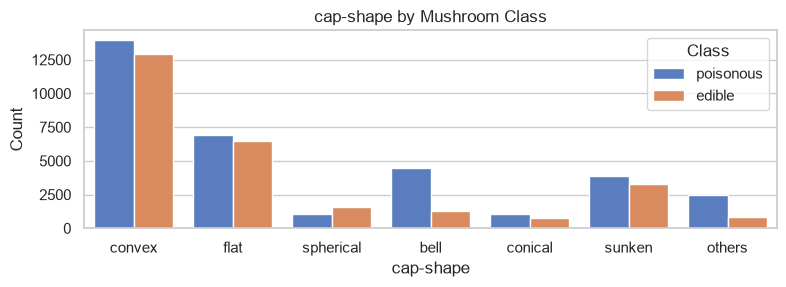

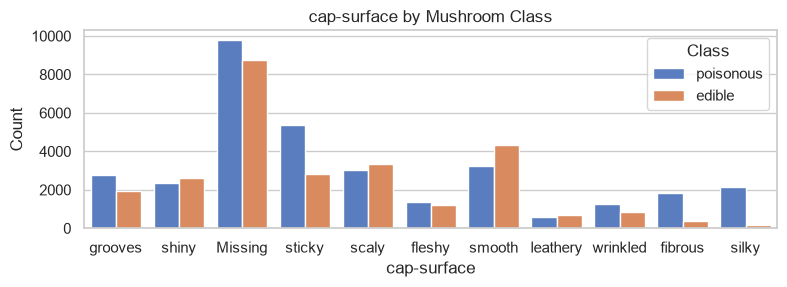

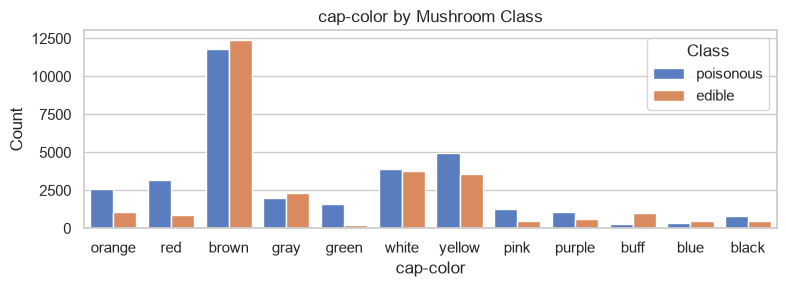

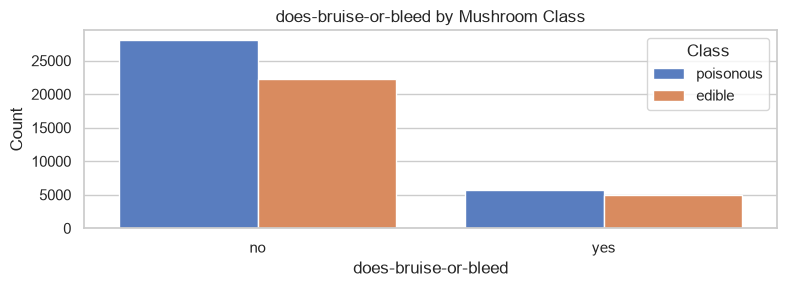

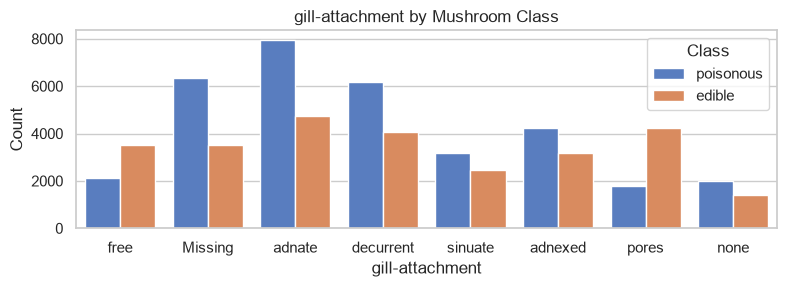

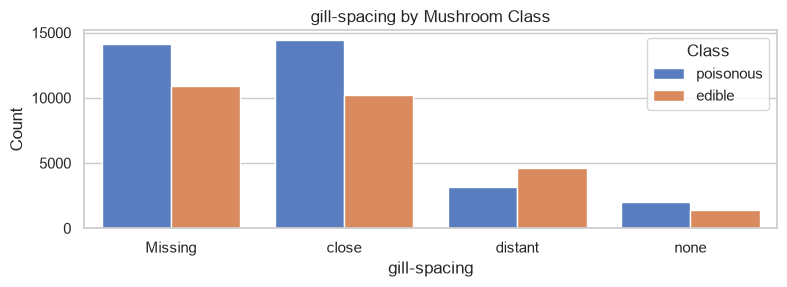

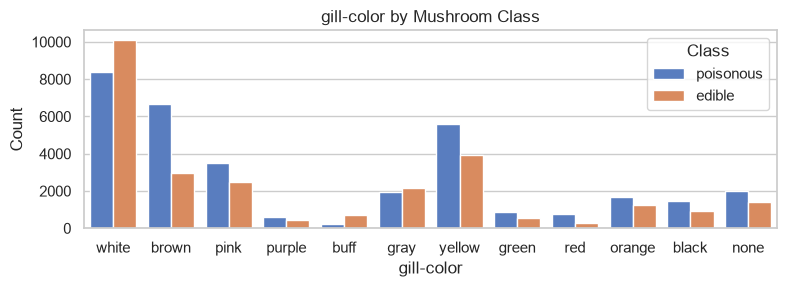

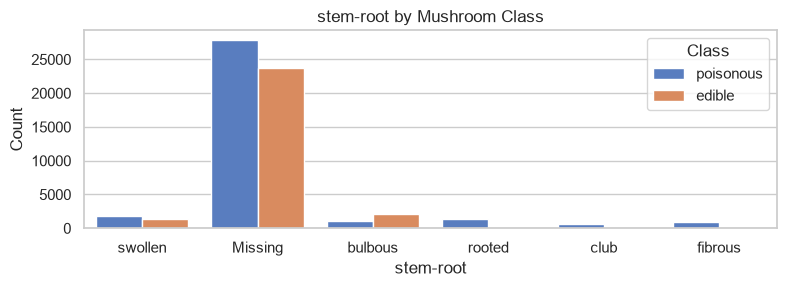

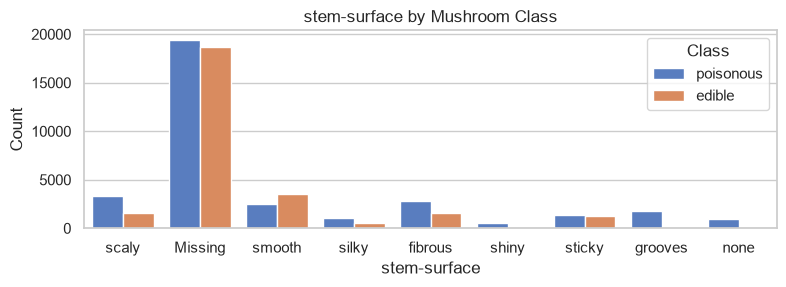

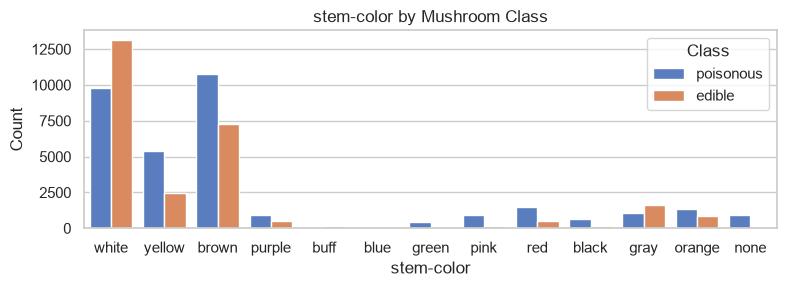

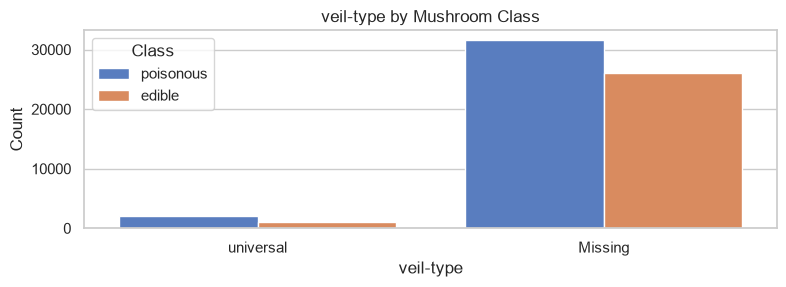

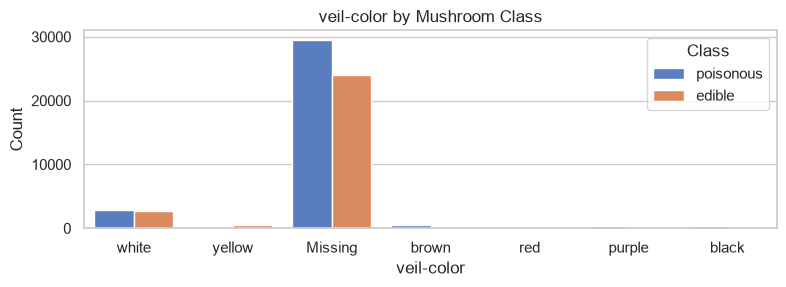

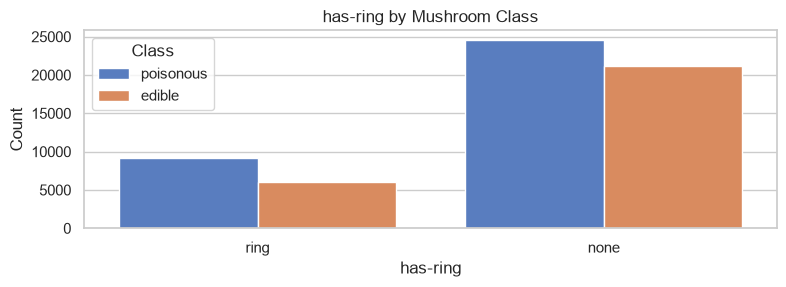

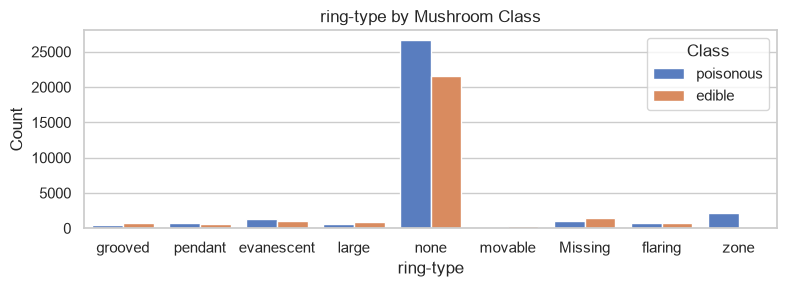

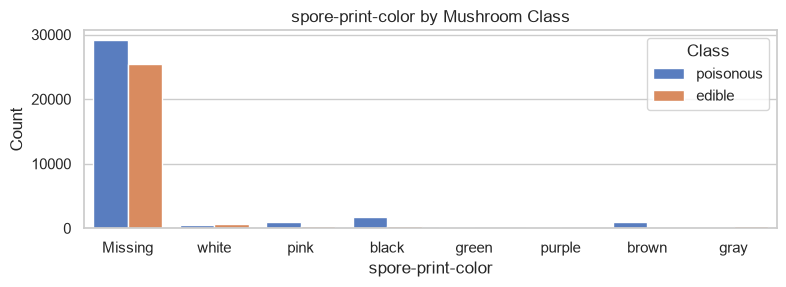

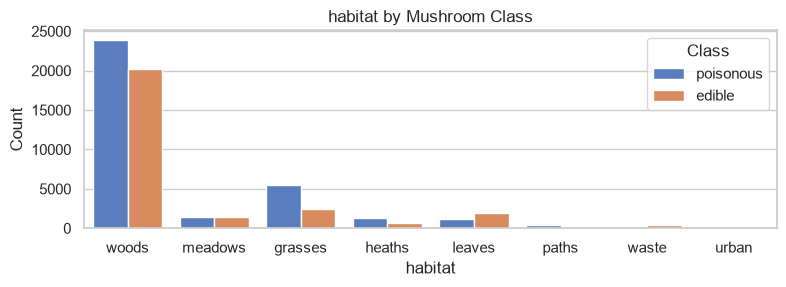

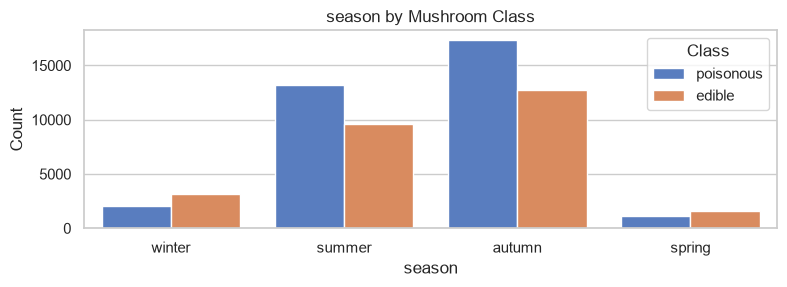

/var/folders/qy/yl4hyv4s5kz52wg1qlh36y_w0000gn/T/ipykernel_28242/2594754230.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Class")


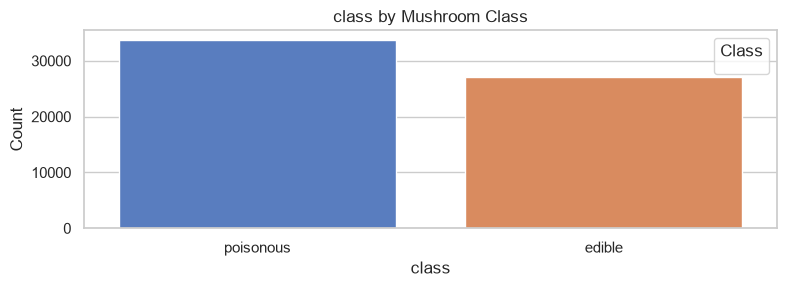

In [49]:
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(data=df, x=col, hue="class")
    plt.title(f"{col} by Mushroom Class")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Class")
    plt.tight_layout()
    plt.show()

#### Interpretation of Categorical Statistics:
- `stem-color`, `stem-surface`, and `stem-root` each have unique values that are distinctly poisonous. This could prove to be a helpful predictor when building our classification model
- `cap-surface`, `stem-surface`, `stem-root`, `veil-type`, `veil-color`, and `spore-print-color` each have **missing** as their mode, suggesting a clear lack of the presence of these features in some of the mushrooms. 

### 4.4 Visualizing Key Individual Attributes

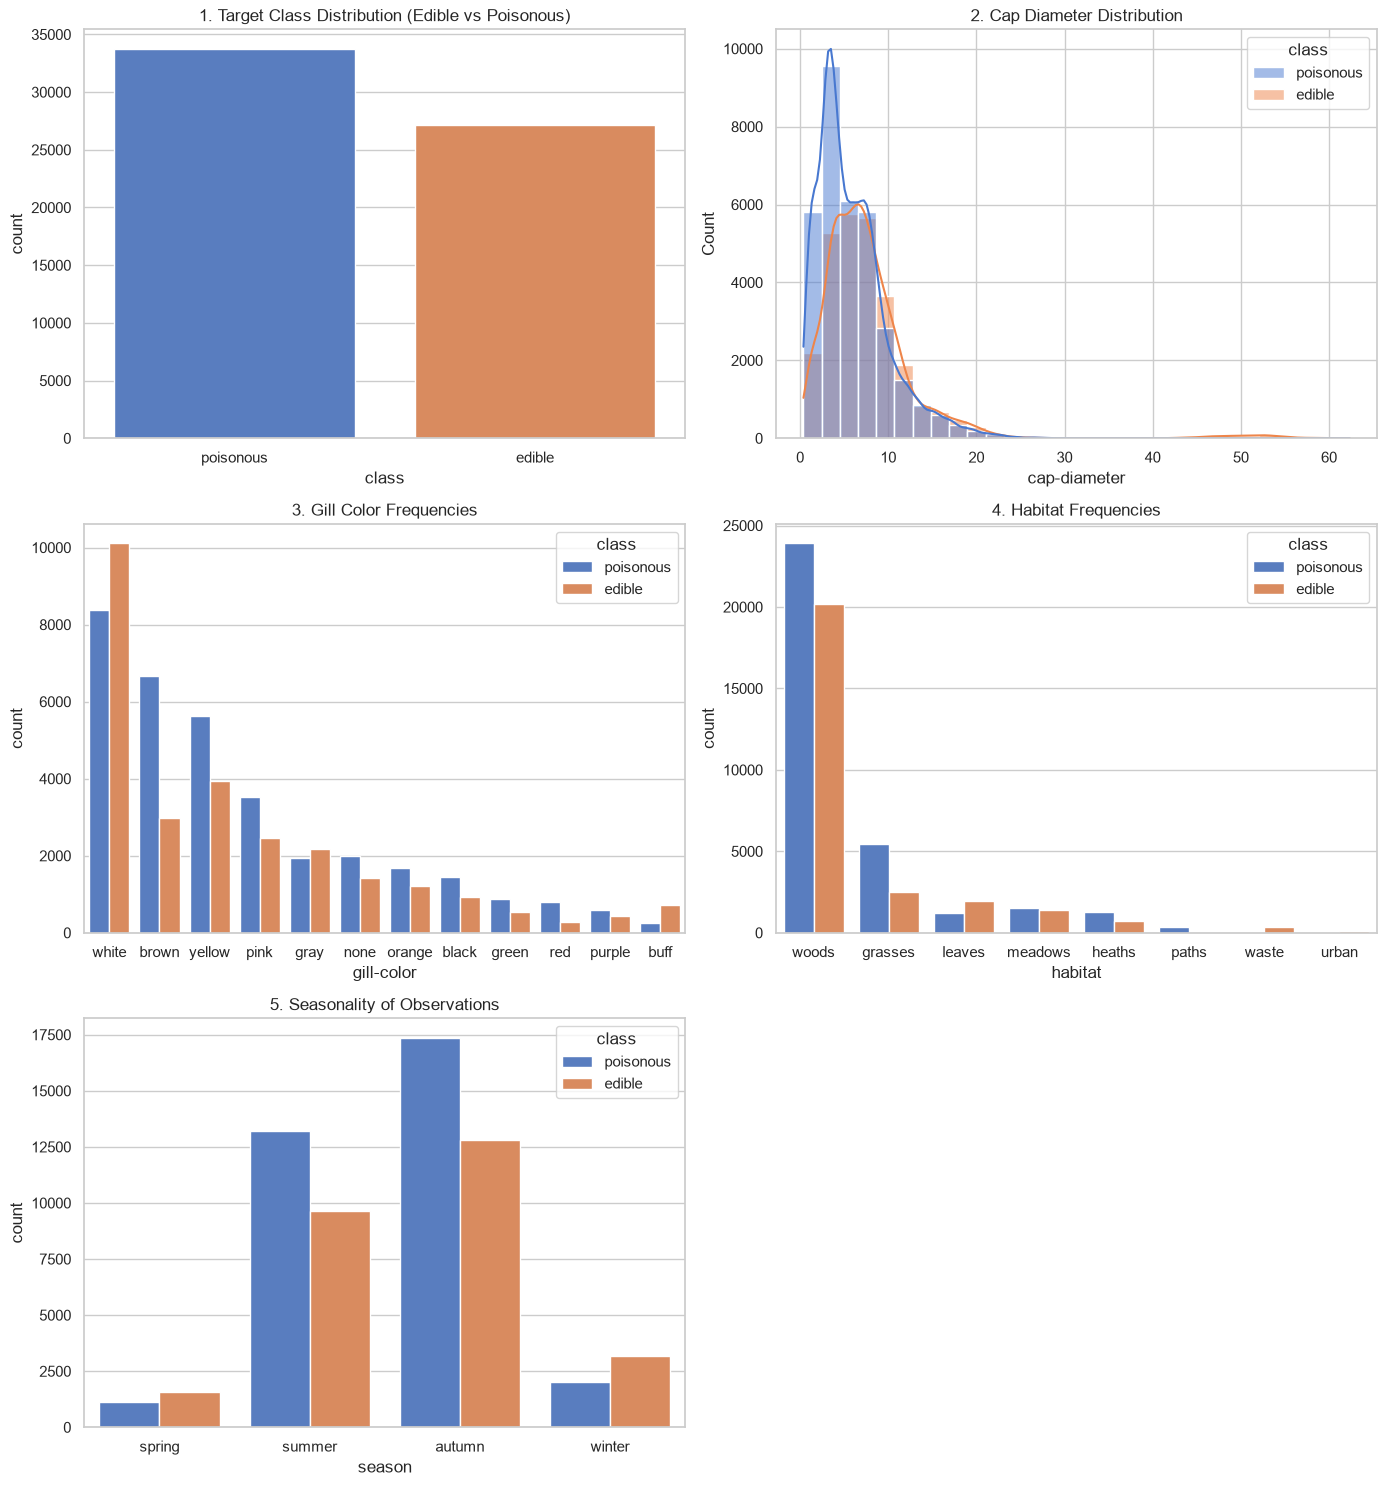

In [59]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. Target Distribution
sns.countplot(data=df, x='class', ax=axes[0, 0], hue = "class")
axes[0, 0].set_title("1. Target Class Distribution (Edible vs Poisonous)")

# 2. Continuous: Cap Diameter Distribution
sns.histplot(data=df, x='cap-diameter', kde=True, ax=axes[0, 1], hue = "class", bins=30)
axes[0, 1].set_title("2. Cap Diameter Distribution")

# 3. Categorical: Gill Color
sns.countplot(data=df, x='gill-color', order=df['gill-color'].value_counts().index, ax=axes[1, 0], hue = "class")
axes[1, 0].set_title("3. Gill Color Frequencies")

# 4. Categorical: Habitat
sns.countplot(data=df, x='habitat', order=df['habitat'].value_counts().index, ax=axes[1, 1], hue = "class")
axes[1, 1].set_title("4. Habitat Frequencies")

# 5. Categorical: Season
sns.countplot(data=df, x='season', order=['spring', 'summer', 'autumn', 'winter'], ax=axes[2, 0], hue = "class")
axes[2, 0].set_title("5. Seasonality of Observations")

# Hide extra subplot
fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()

#### Visualization Interpretations:
1. **Class Distribution:** The dataset is well-balanced (~55% poisonous, ~45% edible), preventing extreme class imbalance issues during modeling.
2. **Cap Diameter:** Heavily unimodal and right-skewed. Most specimens measure between 2 cm and 10 cm.
3. **Gill Color:** High variance across 12 distinct categories. White, brown, and yellow dominate.
4. **Habitat:** Woods and grasses form the dominant ecological habitats.
5. **Season:** Autumn accounts for the vast majority, aligning with natural fungal seasonality.

### 4.5 Visualizing Relationships Between Attributes

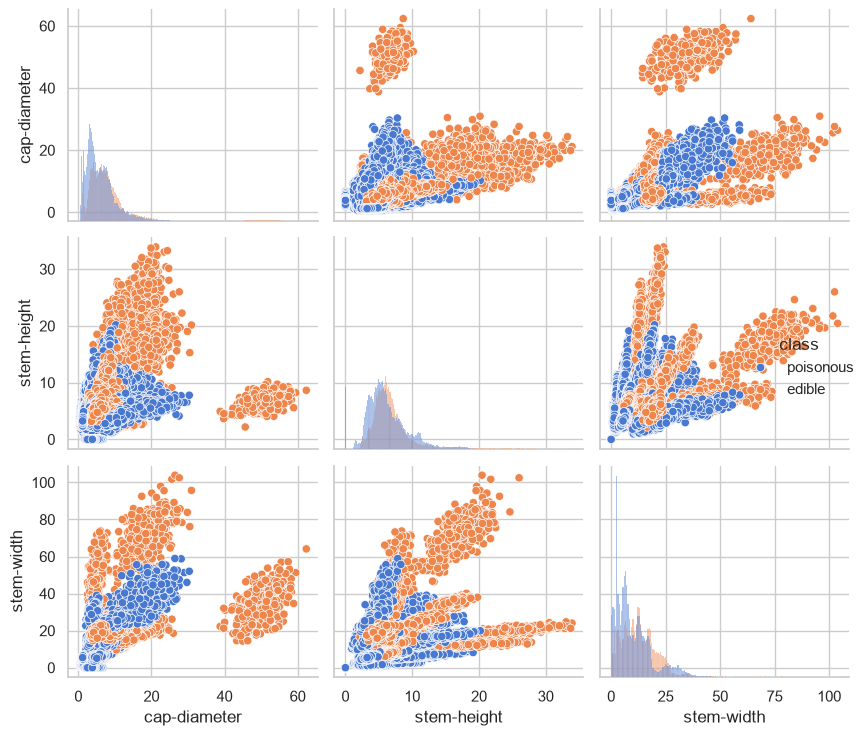

In [51]:
# Pairsplot of numerical attributes by edibility
sns.pairplot(
    df,
    vars=num_cols,
    hue="class",
    diag_kind="hist"
)
plt.tight_layout()
plt.show()

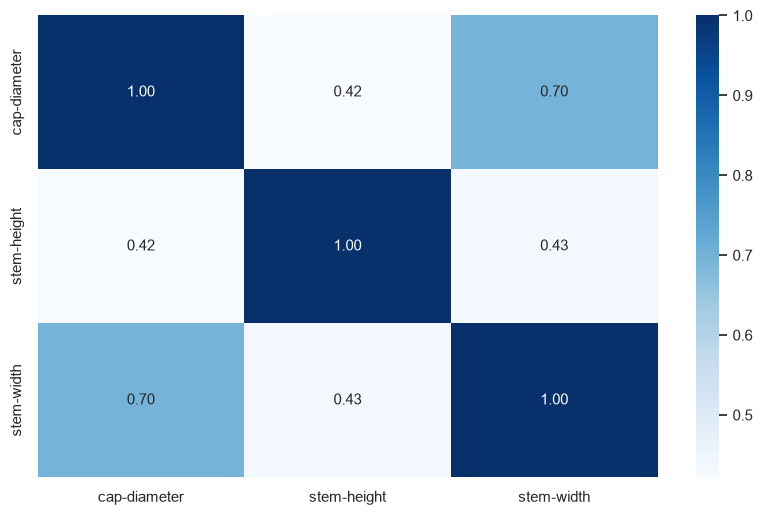

In [52]:
# Correlation Matrix among continuous variables
corr_matrix = df[['cap-diameter', 'stem-height', 'stem-width']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.show()

#### Relationship Interpretations:
- `stem-width` and `stem-height` share a positive correlation ($r \approx 0.43$). Mushrooms with wider stems naturally grow taller to support larger cap mass.
- `cap-diameter` correlates strongly with `stem-width` ($r \approx 0.70$), demonstrating proportional physical growth constraints in fungal anatomy.

### 4.6 Feature Relationships with Target Class

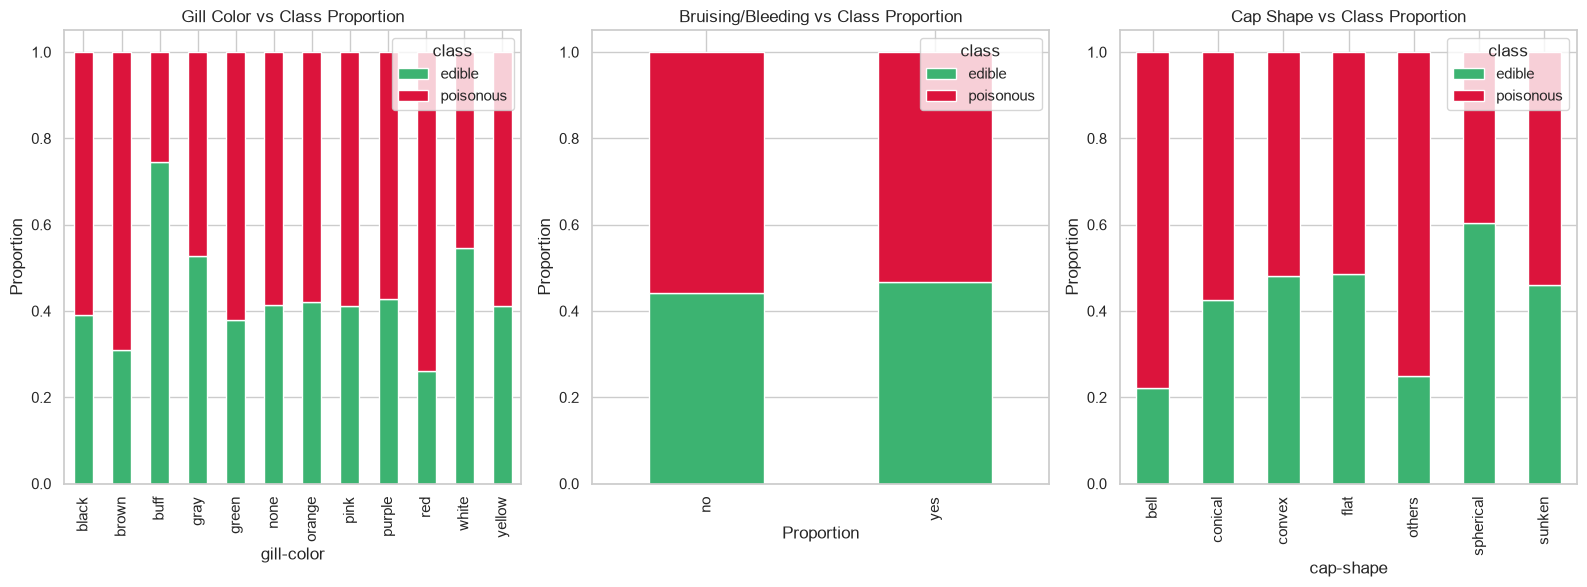

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 1. Gill Color vs Target (Cross-tabulation)
ct_gill = pd.crosstab(df['gill-color'], df['class'], normalize='index')
ct_gill.plot(kind='bar', stacked=True, ax=axes[0], color=['mediumseagreen', 'crimson'])
axes[0].set_title("Gill Color vs Class Proportion")
axes[0].set_ylabel("Proportion")

# 2. Bruising/Bleeding vs Target
ct_bruise = pd.crosstab(df['does-bruise-or-bleed'], df['class'], normalize='index')
ct_bruise.plot(kind='bar', stacked=True, ax=axes[1], color=['mediumseagreen', 'crimson'])
axes[1].set_title("Bruising/Bleeding vs Class Proportion")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Proportion")


# 3. Cap Shape vs Target
ct_cap = pd.crosstab(df['cap-shape'], df['class'], normalize='index')
ct_cap.plot(kind='bar', stacked=True, ax=axes[2], color=['mediumseagreen', 'crimson'])
axes[2].set_title("Cap Shape vs Class Proportion")
axes[2].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

#### Key Predictive Risk Findings:
1. **Gill Color:** Specific colors exhibit extreme edibility signals. For instance, green or buff gills correlate almost entirely with poisonous instances, whereas purple/brown gills lean towards edibility.
2. **Bruising/Bleeding:** Mushrooms that do not bruise or bleed have a higher relative proportion of toxicity compared to bruising species, providing strong predictive interaction features.
3. **Cap Shape:**  Both bell & others cap-shape observations have a significantly higher proportion of poisonous mushrooms compared to edible. Spherical mushrooms have a higher proportion of edibility. 


### 4.7 Feature Engineering

**Derived Features:** 

   * `has-stem` Mushrooms with `stem-height` and `stem-width` both equal to 0 were exclusively poisonous. A binary flag capturing stem presence or absence directly encodes this pattern as a single feature rather than relying on a model to learn it from two separate raw measurements.

   * `size-score` (composite numeric feature): Since we found in our analysis that edible mushrooms tend to be consistently larger than poisonous ones across all three numeric dimensions, a combined size metric (cap-diameter + stem-height + scaled stem-width) could capture overall mushroom "size" as a single feature rather than having a model learn this size relationship across independent but correlated variables. Correlation matrix showed high correlation between the numerical features. Size would eliminate redundancy & increase parsimony. 

   * `cap-shape` + `stem-presence` interaction: Our investigation into the "others" cap-shape category revealed that it splits into very different subgroups depending on stem presence and size (a stemless, exclusively poisonous subgroup vs. a large-bodied, always-edible subgroup). An interaction feature combining cap-shape with the stem presence feature (`has-stem` binary flag) could capture this conditional pattern more directly and account for the effect that one has on the other.

Justification for `has-stem` variable

In [54]:
zero_stem = df[(df['stem-height'] == 0) | (df['stem-width'] == 0)] 
print(f"Rows with stem-height or stem-width == 0: {len(zero_stem)}")
print(f"Percentage of dataset: {(len(zero_stem) / len(df) * 100):.2f}%")

print("\nClass breakdown (Poisonous vs Edible) for these rows:")
print(zero_stem['class'].value_counts(normalize=True).round(3))

print("\nOverall class breakdown for comparison:")
print(df['class'].value_counts(normalize=True).round(3))

print("\nCap-shape breakdown for these rows:")
print(zero_stem['cap-shape'].value_counts())

Rows with stem-height or stem-width == 0: 915
Percentage of dataset: 1.50%

Class breakdown (Poisonous vs Edible) for these rows:
class
poisonous    1.0
Name: proportion, dtype: float64

Overall class breakdown for comparison:
class
poisonous    0.554
edible       0.446
Name: proportion, dtype: float64

Cap-shape breakdown for these rows:
cap-shape
others    915
Name: count, dtype: int64


Engineering `has-stem` feature

In [55]:
df['has-stem'] = ~((df['stem-height'] == 0) & (df['stem-width'] == 0))
df['has-stem'] = df['has-stem'].map({True: 'yes', False: 'no'})

print(df.groupby('has-stem')['class'].value_counts(normalize=True).round(3))

has-stem  class    
no        poisonous    1.000
yes       poisonous    0.547
          edible       0.453
Name: proportion, dtype: float64


Engineering `size-score` (combined size measurements)

In [56]:
df['size-score'] = df['cap-diameter'] + df['stem-height'] + (df['stem-width']/10) # Divide by 10 to account for unit differences

## 5. Exceptional Work

### 5.1 Dimensionality Reduction: PCA Visualization & Analysis

We implement a PCA pipeline incorporating one-hot encoding for categorical variables and median imputation for continuous attributes to project the high-dimensional feature space down to 2 components.

Explained Variance Ratio by 2 Components: 0.2445


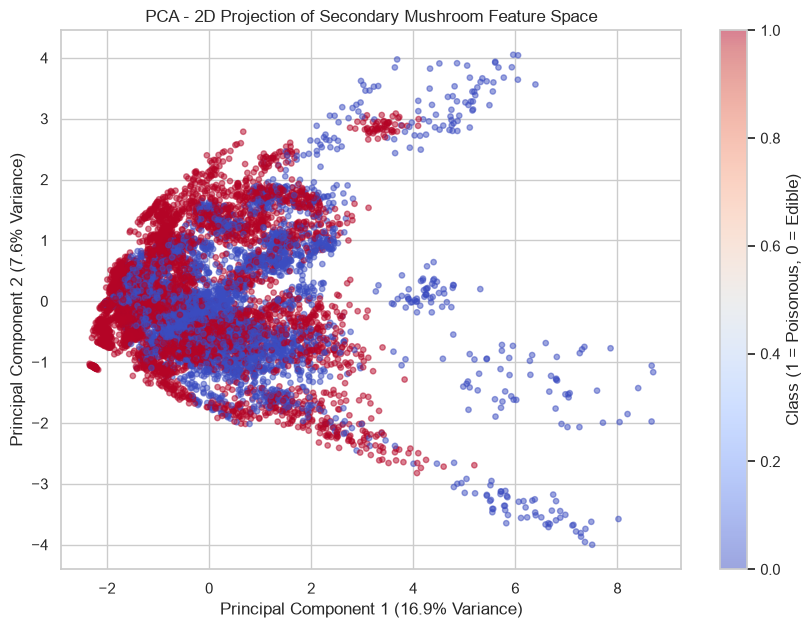

In [57]:
# Sample subset for high-performance dimensionality reduction
sample_df = df.sample(n=10000, random_state=42)

X = sample_df.drop('class', axis=1)
y = sample_df['class']

# Pipeline components
num_features = ['cap-diameter', 'stem-height', 'stem-width']
cat_features = [c for c in X.columns if c not in num_features]

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Fit and Transform (Running Preprocessor on all of X)
X_processed = preprocessor.fit_transform(X)

# PCA Execution
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

print(f"Explained Variance Ratio by 2 Components: {pca.explained_variance_ratio_.sum():.4f}")

# Visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=(y == 'poisonous').astype(int), 
                      cmap='coolwarm', alpha=0.5, s=15)
plt.colorbar(scatter, label='Class (1 = Poisonous, 0 = Edible)')
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.title("PCA - 2D Projection of Secondary Mushroom Feature Space")
plt.show()

### 5.2 PCA Interpretation
* **Separability:** The PCA plot illustrates distinct structural clusters in lower-dimensional space. While there is overlap in the center, specific clusters on the margins consist almost purely of edible or poisonous instances.
* **Non-linear Classification Indication:** Because linear PCA components yield overlapping clusters, non-linear classifiers (such as Gradient Boosted Trees or Random Forests) or higher-dimensional Kernel methods will be required to achieve near 100% recall.